In [15]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.feature_selection import SelectKBest, f_regression




In [3]:
# Load the movies_scaled_dummies.csv file from the data folder
movies_scaled = pd.read_csv('../data/movies_scaled_dummies.csv')
movies_scaled.head()

,Budget,Gross,Release Date,Runtime,Rating,Rating Count,Net Profit,ROI,Genre_Frequency,MPAA Rating_G,...,Genre_Family,Genre_Fantasy,Genre_History,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,-1.284438,296000000.0,10,-1.100607,-1.146270,-0.831512,288500000.0,38.466667,0.051282,0,...,0,0,0,0,0,1,0,0,0,0
1,-1.284438,145793296.0,12,-0.832114,0.549913,-0.776143,138293296.0,18.439106,0.185404,0,...,0,0,0,0,0,0,0,0,0,0
2,-1.191530,71079915.0,7,-0.787365,0.323756,-0.775063,58079915.0,4.467686,0.031558,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.174637,161001698.0,12,1.226329,0.323756,-0.775063,147001698.0,10.500121,0.015779,0,...,0,0,0,0,0,0,0,0,1,0
4,-1.157745,84431625.0,4,-0.474124,0.662992,-0.742398,69431625.0,4.628775,0.110454,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Split the data into 70% training and 30% testing sets
# We can't predict Gross with ROI or Net Profits so we will use all three as potential target variables

yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled[yfeatures]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

In [5]:
# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross, ROI, and Net Profit revenue on the test set
y_pred = rf.predict(X_test)

In [6]:
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")


Training R^2 Score: 0.9241
Mean Squared Error: 13398669612440102.0000
Mean Absolute Error: 70442718.3494
R^2 Score: 0.4595


Not The best model. Lets try it with just Gross as a prediction

In [7]:

X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
# Show training R^2 score
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9402
Mean Squared Error: 21408826129249596.0000
Mean Absolute Error: 109427513.6443
R^2 Score: 0.5770


In [8]:

X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the ROI revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9286
Mean Squared Error: 28.8208
Mean Absolute Error: 2.4465
R^2 Score: 0.5161


In [9]:

X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Net Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the Net profit revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, rf.predict(X_train))
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Training R^2 Score: 0.9252
Mean Squared Error: 18636857595938356.0000
Mean Absolute Error: 101617691.6912
R^2 Score: 0.4922


Comparing the differnt calculations we can use for y features, Gross seems to have the best corrilation when using random forest. Gross will be used in the next tests.

Now we can see how Xboost compairs

In [10]:
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

# Create and fit an XGBoost Regressor model on the training set
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = xgb.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"XGBoost Mean Squared Error: {mse:.4f}")
print(f"XGBoost Mean Absolute Error: {mae:.4f}")
print(f"XGBoost R^2 : {r2:.4f}")

XGBoost Mean Squared Error: 21262939878855960.0000
XGBoost Mean Absolute Error: 107739359.0987
XGBoost R^2 : 0.5799


XGBoost slightly out preforms random forest. Lets see LinearRegression

In [11]:
# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, lr.predict(X_train))

print(f"Training Linear Regression R^2 Score: {train_r2:.4f}")
print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression R^2 Score: {r2:.4f}")

Training Linear Regression R^2 Score: 0.6345
Linear Regression Mean Squared Error: 19982704998889668.0000
Linear Regression Mean Absolute Error: 106232011.5919
Linear Regression R^2 Score: 0.6052


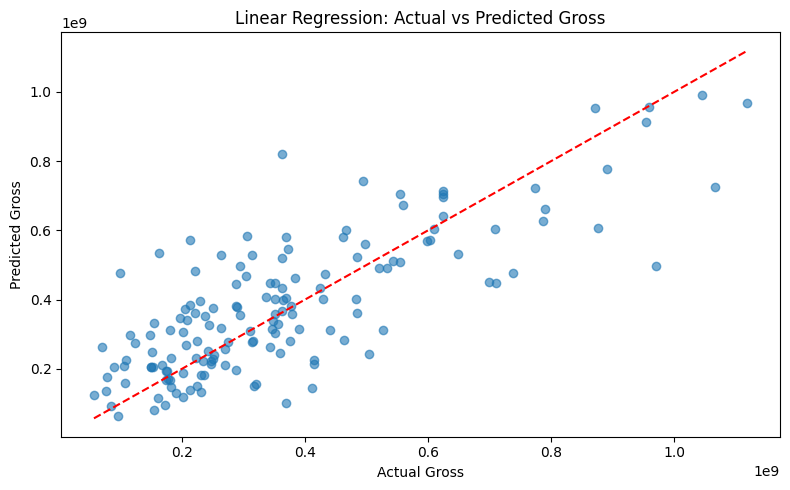

In [12]:
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Linear Regression: Actual vs Predicted Gross")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.tight_layout()
plt.show()

Linear regression out preformes the tree models.

In [13]:

# Create and fit a Support Vector Regressor model on the training set
svr = SVR()
svr.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = svr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
train_r2 = r2_score(y_train, svr.predict(X_train))

print(f"Training SVR R^2 Score: {train_r2:.4f}")
print(f"SVR Mean Squared Error: {mse:.4f}")
print(f"SVR Mean Absolute Error: {mae:.4f}")
print(f"SVR R^2 Score: {r2:.4f}")

Training SVR R^2 Score: -0.0825
SVR Mean Squared Error: 54265107766325096.0000
SVR Mean Absolute Error: 165470378.1975
SVR R^2 Score: -0.0722


Support Vector Machine preforms extremely poor.

Lets use the linear regression model and look at some hyperparameters

In [22]:
# Split the data into 70% training and 30% testing sets
# We can't predict Gross with ROI or Net Profits so we will use all three as potential target variables
Xfeatures = ['Budget','Release Date','Runtime','Rating','Rating Count','Genre_Frequency']
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled[Xfeatures]
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=X['Genre_Frequency'])

In [23]:
# Create a pipeline for feature selection and regression
pipeline = Pipeline([
    ('selectkbest', SelectKBest()),
    ('regressor', LinearRegression())
])
# Feature Selection using SelectKBest
k = [k+1 for k in range(len(X_train.columns))]
grid_params = {'selectkbest__k': k}
# Grid search for the best number of features to select
lr_grid_cv = GridSearchCV(pipeline, param_grid=grid_params, cv=5, n_jobs=-1, scoring='r2')
lr_grid_cv.fit(X_train, y_train)


score_mean = lr_grid_cv.cv_results_['mean_test_score']
score_std = lr_grid_cv.cv_results_['std_test_score']
cv_k = [k for k in lr_grid_cv.cv_results_['param_selectkbest__k']]


In [32]:
#Print the `best_params_` attribute of `lr_grid_cv`

print(lr_grid_cv.best_params_)

{'selectkbest__k': 6}


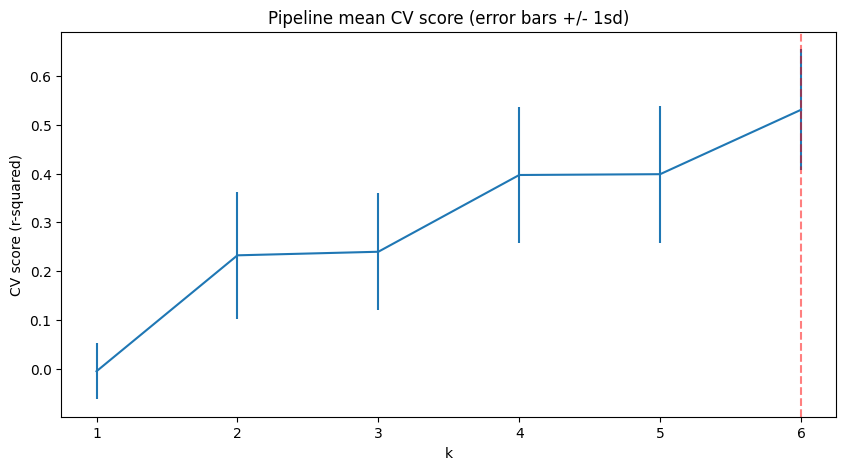

In [25]:
#Assign the value of k from the above dict of `best_params_` and assign it to `best_k`
best_k = lr_grid_cv.best_params_['selectkbest__k']
plt.subplots(figsize=(10, 5))
plt.errorbar(cv_k, score_mean, yerr=score_std)
plt.axvline(x=best_k, c='r', ls='--', alpha=.5)
plt.xlabel('k')
plt.ylabel('CV score (r-squared)')
plt.title('Pipeline mean CV score (error bars +/- 1sd)');

In [47]:
#Get the linear model coefficients from the `coef_` attribute and store in `coefs`,
#get the matching feature names from the column names of the dataframe,
#and display the results as a pandas Series with `coefs` as the values and `features` as the index,
#sorting the values in descending order
selected = lr_grid_cv.best_estimator_.named_steps.selectkbest.get_support()
coefs = lr_grid_cv.best_estimator_.named_steps['regressor'].coef_
features = X_train.columns[selected]
df_coefs = pd.Series(coefs, index=features).sort_values(ascending=False)

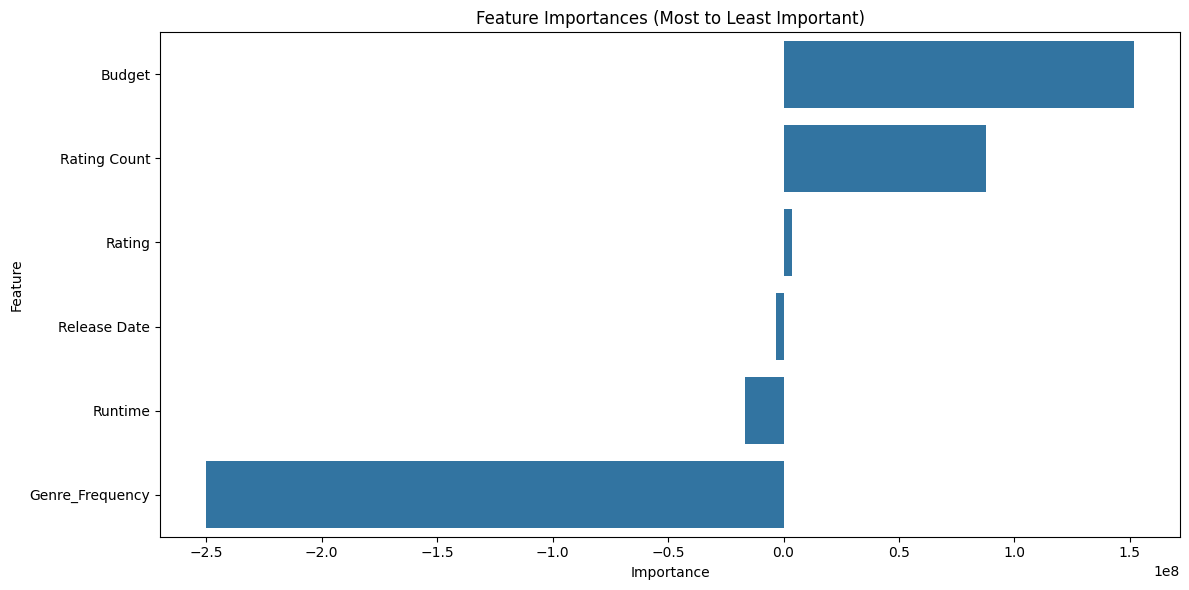

In [48]:
# Plot the feature importances

plt.figure(figsize=(12, 6))
sns.barplot(x=df_coefs.values, y=df_coefs.index)
plt.title('Feature Importances (Most to Least Important)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [53]:
# Perform K-Fold cross validation on the Random Forest model
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=20, shuffle=True, random_state=42)
lr= LinearRegression()
cv_scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')

print(f"K-Fold Cross Validation R^2 Scores: {cv_scores}")
print(f"Mean R^2 Score: {cv_scores.mean():.4f}")

K-Fold Cross Validation R^2 Scores: [0.6828073  0.72890673 0.39834451 0.69929456 0.46556191 0.40636412
 0.40222452 0.67517089 0.50264873 0.57634906 0.10063679 0.41886272
 0.51583882 0.48309131 0.32835849 0.60832581 0.50340629 0.66133199
 0.58369361 0.59959174]
Mean R^2 Score: 0.5170


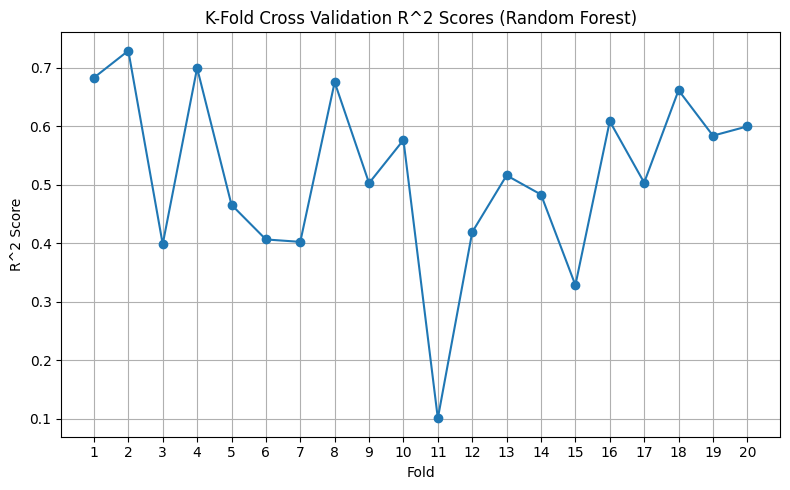

In [54]:
# Plot K-Fold Cross Validation R^2 Scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o')
plt.title('K-Fold Cross Validation R^2 Scores (Random Forest)')
plt.xlabel('Fold')
plt.ylabel('R^2 Score')
plt.xticks(range(1, len(cv_scores) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Load the StandardScaler from a pickle file
scaler = joblib.load('../data/standard_scaler.pkl')



X_full = movies_scaled
y_full = movies_scaled['Gross']

# Create pipeline with StandardScaler and RandomForestRegressor
pipeline = Pipeline([
    ('scaler', scaler),
    ('lr', LinearRegression())
])

# Fit pipeline
pipeline.fit(X_full, y_full)

# Predict
train_r2 = r2_score(y_full, pipeline.predict(X_full))
print("Lineaer regression model trained on the full dataset.")
print(f"Training R^2 Score: {train_r2:.4f}")

Lineaer regression model trained on the full dataset.
Training R^2 Score: 1.0000


In [ ]:
# Export the trained pipeline to a pickle file
joblib.dump(pipeline, '../data/random_forest_pipeline.pkl')
print("Pipeline exported to ../data/random_forest_pipeline.pkl")